# PyTorch Basics: Training Your First Model

This notebook covers:
- Complete training loop
- Optimizers (SGD, Adam)
- Training vs evaluation mode
- Saving and loading models
- Training a real MNIST classifier

## The Training Pipeline

```
┌────────────────────────────────────────┐
│      Training Loop                     │
├────────────────────────────────────────┤
│  1. Forward pass                       │
│  2. Compute loss                       │
│  3. Zero gradients                     │
│  4. Backward pass                      │
│  5. Update weights                     │
│  6. Repeat                             │
└────────────────────────────────────────┘
```


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


PyTorch version: 2.13.0
Using device: cpu


## 1. Prepare Data


In [2]:
# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load datasets
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


100%|██████████| 9.91M/9.91M [00:22<00:00, 447kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 94.4kB/s]
100%|██████████| 1.65M/1.65M [00:05<00:00, 299kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.32MB/s]

Training samples: 60000
Test samples: 10000
Training batches: 938
Test batches: 10


## 2. Define Model


In [3]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = Net().to(device)
print(model)


Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 3. Define Loss and Optimizer

### Common Optimizers

```
SGD - Stochastic Gradient Descent
  w = w - lr * gradient

Adam - Adaptive Moment Estimation  
  w = w - lr * adaptive_gradient
  (uses momentum and adaptive learning rates)

AdamW - Adam with Weight Decay
  Better regularization than Adam
```


In [4]:
# Loss function
criterion = nn.NLLLoss()  # Negative Log Likelihood (for log_softmax output)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")


Loss function: NLLLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 4. Training Loop


In [5]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()  # Set model to training mode
    
    total_loss = 0
    correct = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        # Move data to device
        data, target = data.to(device), target.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        output = model(data)
        
        # Compute loss
        loss = criterion(output, target)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        
        # Print progress
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\t'
                  f'Loss: {loss.item():.6f}')
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / len(train_loader.dataset)
    print(f'\nTraining set: Average loss: {avg_loss:.4f}, '
          f'Accuracy: {correct}/{len(train_loader.dataset)} ({accuracy:.2f}%)\n')
    
    return avg_loss, accuracy

print("Training function defined!")


Training function defined!


## 5. Evaluation Loop


In [6]:
def test(model, device, test_loader):
    model.eval()  # Set model to evaluation mode
    
    test_loss = 0
    correct = 0
    
    with torch.no_grad():  # Disable gradient computation
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    
    print(f'Test set: Average loss: {test_loss:.4f}, '
          f'Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    
    return test_loss, accuracy

print("Test function defined!")


Test function defined!


## 6. Train the Model!


In [7]:
# Training
epochs = 1
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model, device, train_loader, optimizer, epoch)
    test_loss, test_acc = test(model, device, test_loader)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

print("Training complete!")


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.290334
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.301170
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.184670
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.233937
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.076904
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.158421
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.023076
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.046860
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.160492
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.082093

Training set: Average loss: 0.2098, Accuracy: 56156/60000 (93.59%)

Test set: Average loss: 0.0477, Accuracy: 9849/10000 (98.49%)

Training complete!


## 7. Visualize Results


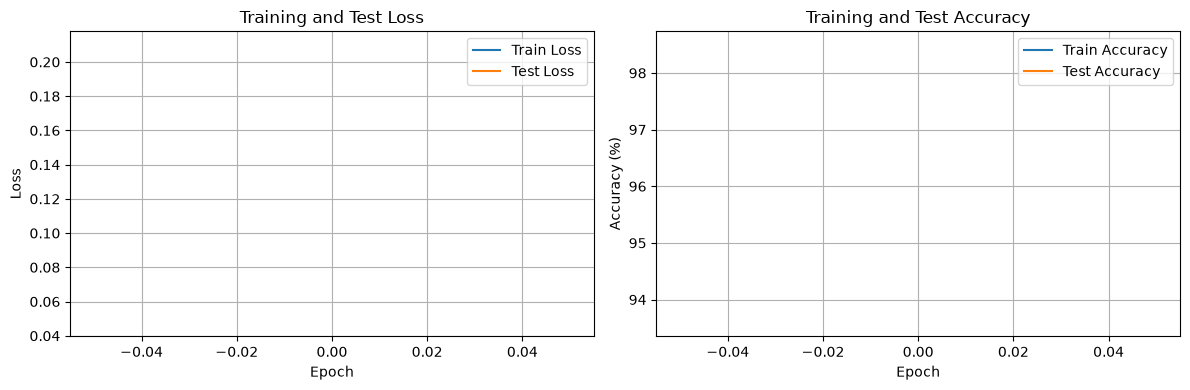

Final test accuracy: 98.49%


In [8]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(train_losses, label='Train Loss')
ax1.plot(test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_accs, label='Train Accuracy')
ax2.plot(test_accs, label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

print(f"Final test accuracy: {test_accs[-1]:.2f}%")


## 8. Saving and Loading Models


In [9]:
# Save model (state dict recommended)
torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved!")

# Load model
loaded_model = Net().to(device)
loaded_model.load_state_dict(torch.load('mnist_model.pth'))
loaded_model.eval()
print("Model loaded!")

# Test loaded model
test_loss, test_acc = test(loaded_model, device, test_loader)
print(f"Loaded model accuracy: {test_acc:.2f}%")

# Save complete checkpoint
checkpoint = {
    'epoch': epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_losses[-1],
    'test_loss': test_losses[-1],
}
torch.save(checkpoint, 'checkpoint.pth')
print("Checkpoint saved!")

# Load checkpoint
checkpoint = torch.load('checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
print(f"Checkpoint loaded from epoch {checkpoint['epoch']}")


Model saved!
Model loaded!
Test set: Average loss: 0.0477, Accuracy: 9849/10000 (98.49%)

Loaded model accuracy: 98.49%
Checkpoint saved!
Checkpoint loaded from epoch 1


## 📝 Summary

✅ Built complete training pipeline  
✅ Trained MNIST classifier  
✅ Evaluated model performance  
✅ Saved and loaded models  
✅ Visualized training progress  

### Key Takeaways

1. **Always zero gradients** before backward pass
2. **Use model.train()** during training, **model.eval()** during testing
3. **Use torch.no_grad()** during evaluation to save memory
4. **Save state_dict**, not entire model (more flexible)
5. **Monitor both loss and accuracy**

### Next Steps

- **Next Tutorial**: `intermediate/01_cnn.ipynb` - Advanced CNN architectures
- **Practice**: Train on different datasets (CIFAR-10, Fashion-MNIST)
- **Challenge**: Implement early stopping and learning rate scheduling

### Additional Resources

- [PyTorch Training Tutorial](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)
- [PyTorch Optimization](https://pytorch.org/docs/stable/optim.html)


## 🎯 Practice Exercises


In [10]:
# Exercise 1: Implement early stopping
# Your code here:


# Exercise 2: Add learning rate scheduling
# Your code here:


# Exercise 3: Implement gradient clipping
# Your code here:


# Exercise 4: Track and plot per-class accuracy
# Your code here:
